# CRLB Figure

In [12]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path

import math
import matplotlib.pyplot as plt
import numpy as np
import torch

In [13]:
path = "../"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [14]:
import decode

print(decode.__file__)
from decode.neuralfitter.train import setup_cfg

random_seed = 42
torch.manual_seed(random_seed)
%config InlineBackend.figure_format='retina'

/home/shahao/projects/DECODE-Plex/notebook/../decode/__init__.py


In [ ]:
# some paths and hardware settings

# path_model = "/home/shah/projects/DECODE_PLEX/outputs/pixilation/2025-04-01_14-59-48-871160"
path_spline = "../calibration/FigS5-Pos0_231130_BeadsCal_Z_1_MMStack_Default.ome_updown_ul_normal_em_3dcal.mat"
path_trafo = "../calibration/FigS5-Pos0_231130_BeadsCal_Z_1_MMStack_Default.ome_updown_ul_normal_em_trafo.mat" 

# old
path_model = "../outputs/FigS4-dual_color-crlb"

path_model = Path(path_model).expanduser()
path_ckpt = sorted(path_model.glob("*.ckpt"))[0]
path_cfg = path_model / "param_run.yaml"

path_out = "../results/FigS4-crlb"
path_out = Path(path_out).expanduser()

trafo_size_ref = 512
trafo_mirr_dim = 0

device = ["cuda:0"]

path_spline, path_trafo = Path(path_spline).expanduser(), Path(path_trafo).expanduser()

# Emitter Generation

In [16]:
xextent = (50.5, 205.5)
yextent = xextent
zextent = (-600., 600.)

img_shape = (256, 256)
px_size = (100, 100)  # fake, but doesn't matter
frame_extent = ((-0.5, img_shape[0] - 0.5), (-0.5, img_shape[1] - 0.5))

z_steps = 30
n_repetitions = 1000

n_channels = 1
n_frames = z_steps * n_repetitions
n_emitters = n_frames

bg_val = 20
phot_val = 5000

In [17]:
structure = decode.simulation.structures.RandomStructure(
    xextent, yextent, zextent
)


In [18]:
xextent_psf = [-0.5, 255.5]
yextent_psf = xextent_psf
img_shape_psf = list(img_shape)

cfg = decode.io.param.load(path_cfg)
cfg_sim = cfg["Simulation"]

cfg["Hardware"]["device"]["simulation"] = device[0]
cfg_sim["psf_extent"]["x"] = xextent_psf
cfg_sim["psf_extent"]["y"] = yextent_psf
cfg_sim["img_size"] = img_shape_psf
from decode.neuralfitter.train.setup_cfg import setup_psf

psf = setup_psf(cfg, cfg_sim)

2026-04-27 15:05:23 [info     ] Note: PSF normalization is with reference to the saved PSF.
2026-04-27 15:05:25 [info     ] Auto-loaded normalization from calibration file norm=[1.0, 4.891368282591661]
2026-04-27 15:05:25 [info     ] Reassigning or limiting PSF channels. channels_nat=2 ix_in_sim=0 ix_nat=0
2026-04-27 15:05:25 [info     ] Reassigning or limiting PSF channels. channels_nat=2 ix_in_sim=1 ix_nat=0


In [23]:
path = path_trafo if isinstance(path_trafo, Path) else Path(path_trafo)

from decode.neuralfitter.train.setup_cfg import setup_trafo
trafo = setup_trafo(cfg, 'cpu')

# if path.suffix == ".mat":
#     offset = [-14, 0, 0]
#     trafo = decode.io.trafo.load_xyz_trafo(
#         path_trafo,
#         scale=1 / 1000.0,
#         switch_xy=True,
#         shift=(1.0, 1.0, 0.0),
#         reference="trafo_inv_raw",
#         device=device[0],
#     )
#     t_mirr = decode.simulation.trafo.pos.trafo.XYZMirrorAt.from_frame_flip(
#         trafo_size_ref,
#         trafo_mirr_dim,
#         device=device[0],
#     )
#     t_mirr = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(
#         t_mirr,
#         ch=1,
#     )
#     trafo.append(t_mirr)
#     trafo_shift = decode.simulation.trafo.pos.trafo.XYZShiftTransformation(
#         offset, device=device[0]
#     )
#     trafo_shift = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(trafo_shift, 1)

#     # final trafo
#     trafo.append(trafo_shift)
#     trafo = trafo.to("cpu")

# elif path.suffix == ".h5":
#     offset = [0, -23, 0]
#     trafo = decode.io.trafo.load_xyz_trafo(
#         path_trafo,
#         scale=1.0,
#         switch_xy=True,
#         shift=None,
#         reference="trafo_inv_raw",
#         device=device,
#         reverse_trafo=True,
#     )
#     trafo_shift = decode.simulation.trafo.pos.trafo.XYZShiftTransformation(
#         offset, device=device
#     )
#     trafo_shift = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(trafo_shift, 1)

#     # final trafo
#     trafo.append(trafo_shift)
#     trafo = trafo.to("cpu")
    
trafo

2026-04-27 15:06:07 [info     ] Loading transformation.        path=/home/shahao/projects/DECODE_Internal/calibration/Pos0_231130_BeadsCal_Z_1_MMStack_Default.ome_updown_ul_normal_em_trafo.mat reference=trafo_inv_raw
2026-04-27 15:06:07 [info     ] Running experimental function `load_xyz_trafo` tested=True
2026-04-27 15:06:07 [info     ] De-mirroring transformation.   ch=1 dim=0 size_reference=512
2026-04-27 15:06:07 [info     ] Offsets as specified in config.
2026-04-27 15:06:07 [debug    ] Final transformation.          trafo=XYZCompositTransformation([
    XYZShiftTransformation(tensor([1., 1., 0.]), cpu),
    XYZScaleTransformation(0.0010000000474974513, global),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x77006b8f3f40>, None, cpu, True),
    XYZTransformationMatrix(tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 0.9998, -0.0356,  0.0011],
         [-0.0368, -1.0024, -0.0042],
       

XYZCompositTransformation([
    XYZShiftTransformation(tensor([1., 1., 0.]), cpu),
    XYZScaleTransformation(0.0010000000474974513, global),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x77006b8f3f40>, None, cpu, True),
    XYZTransformationMatrix(tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 0.9998, -0.0356,  0.0011],
         [-0.0368, -1.0024, -0.0042],
         [ 0.0052,  0.5089,  1.0000]]])),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x77006b8f3f40>, None, cpu, True),
    XYZScaleTransformation(1000.0, global),
    XYZShiftTransformation(tensor([-1., -1., -0.]), cpu),
    XYZChanneledTransformation(XYZMirrorAt(axis=0, at=511, device=cpu), 1),
    XYZChanneledTransformation(XYZShiftTransformation(tensor([-14,   0,   0]), cpu), 1)
])

In [24]:
cam = decode.simulation.camera.CameraPerfect(sensor_size=img_shape, device=device[0])
cam = [cam] * 2

choric = decode.simulation.trafo.photon.trafo.MultiChoricSplitter(
    torch.tensor([[0.5, 0.5]])
)

In [25]:
mic = decode.simulation.microscope.MicroscopeMultiChannel(
    psf=psf,
    noise= [None, None], # manually, because then we can batch
    frame_range=(0, n_frames),
    ch_range=(0, 2),
)

In [26]:

# we first sample as many as there are z steps and later repat
xyz = structure.sample(z_steps)
xyz[:, 2] = torch.linspace(zextent[0], zextent[1], z_steps)

phot = torch.ones(z_steps) * phot_val
bg = torch.ones(z_steps) * bg_val * 2 # because crlb calculation
frame_ix = torch.arange(z_steps)
id = torch.arange(z_steps)

em = decode.emitter_factory(
    xyz=xyz,
    phot=phot,
    bg=bg,  # for crlb calculation
    frame_ix=frame_ix,
    id=id,
    xy_unit="px",
    px_size=px_size
)
em.populate_crlb_(psf[0])
em = em.repeat(n_repetitions, step_frames=False)
# resample xy to have different xy positions but same z
em.xyz_px[:, :2] = structure.sample(n_emitters)[:, :2]
em.frame_ix = torch.arange(n_frames)

# with trafo
em_ch = em.clone()
em_ch.xyz_px = trafo.forward(em_ch.xyz_px)
em_ch.phot = choric.forward(em_ch.phot, torch.zeros(len(em_ch), dtype=torch.long))

bg = torch.ones(img_shape) * bg_val
bg = [bg] * 2

In [27]:

import importlib

import decode.simulation.microscope
importlib.reload(decode.simulation.microscope)

frames = mic.forward(em_ch, bg)

frames_noise = []

for ff, cc in zip(frames, cam, strict=True):
    frames_noise.append(torch.cat([cc.forward(xx).cpu() for xx in torch.split(ff, 2048, dim=0)]))

frames = frames_noise

2026-04-27 15:06:26 [warning  ] Overwriting/Inferring code from phot instead of em.code.


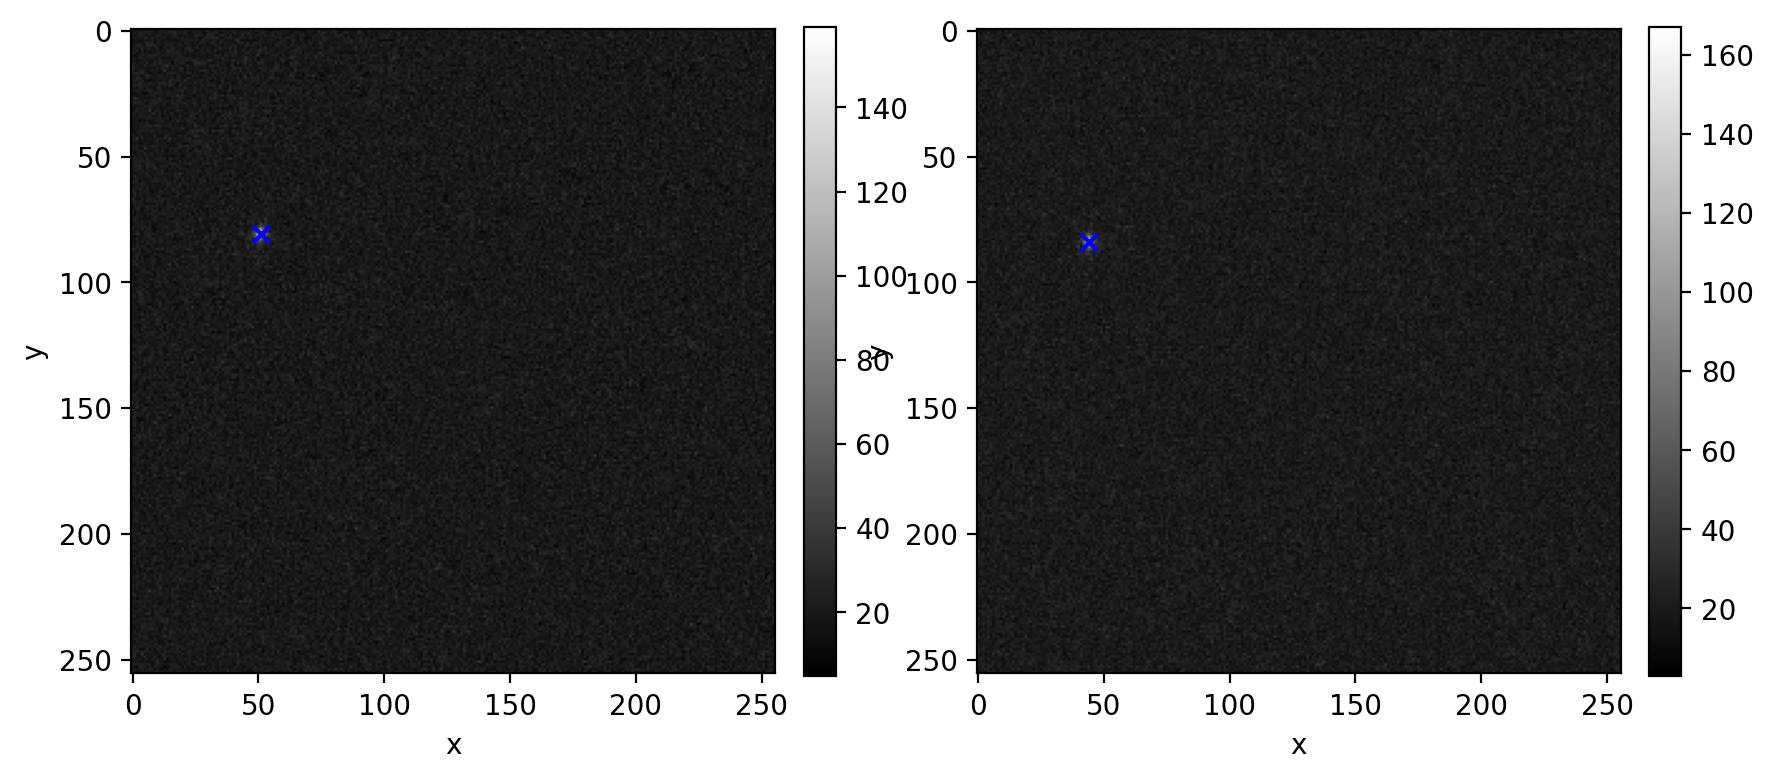

In [28]:
f_ix = 15000

f, ax = plt.subplots(1, 2, figsize=(10, 5))
plt.sca(ax[0])
decode.plot.PlotFrameCoord(
    frames[0][f_ix],
    pos_out=em_ch.iframe[f_ix].xyz_px[:, 0]
).plot()

plt.sca(ax[1])
decode.plot.PlotFrameCoord(
    frames[1][f_ix],
    pos_out=em_ch.iframe[f_ix].xyz_px[:, 1]
).plot()


# Fully Automatic Inference

In [29]:
import decode.neuralfitter.inference.functional as infer_func
from omegaconf import OmegaConf
cfg = decode.io.param.load(path_cfg)

# patches
cfg["Paths"]["trafo"] = path_trafo
cfg = decode.io.param.patch_img_size(cfg, img_shape, scenario=["Simulation", "Test"])
cfg["Hardware"]["device"]["training"] = device[0]

for i in range(2):
    cfg["Camera"][i]["specs"] |= {"flip": {"gain": None, "channel": None}}

# scoped fixes
for s in ["Simulation", "Test"]:
    # pass
    cfg[s]["Transformation"]["Pos"]["glob"]["offset"] = {"x": [0, 0], "y": [0, 0], "z": [0, 0]}

# convenience
# cfg = OmegaConf.create(cfg)
# cfg["Simulation"]["Transformation"]["Pos"]["glob"]["offset"]

In [30]:
path_ckpt = sorted(path_model.glob("*.ckpt"))[0]
em_out, logger = infer_func.infer(
    frames,
    frame_crop=img_shape,
    cfg=cfg,
    model=path_ckpt,
    trafo=trafo,
    mode="multi",
    mode_camera="cameras",
    logger="debug",
    batch_size=4,
    num_workers=0,
    device = device,
)



2026-04-27 15:07:44 [info     ] Running experimental function `infer` tested=False
2026-04-27 15:07:44 [info     ] Running experimental function `load_model` tested=False
2026-04-27 15:07:46 [info     ] No flipping of frames due to camera.
2026-04-27 15:07:46 [info     ] Setting up frame pre-processing in multi-camera mode.
2026-04-27 15:07:46 [info     ] Offsets as specified in config. offset=[(0, 0), (0, 0)]


100%|██████████| 7500/7500 [12:01<00:00, 10.39it/s]


In [31]:
em_out.phot = choric.forward(em_out.phot, torch.zeros(len(em_out), dtype=torch.long)) if em_out.phot.dim()==1 else em_out.phot

In [20]:
len(frames[0])

30000

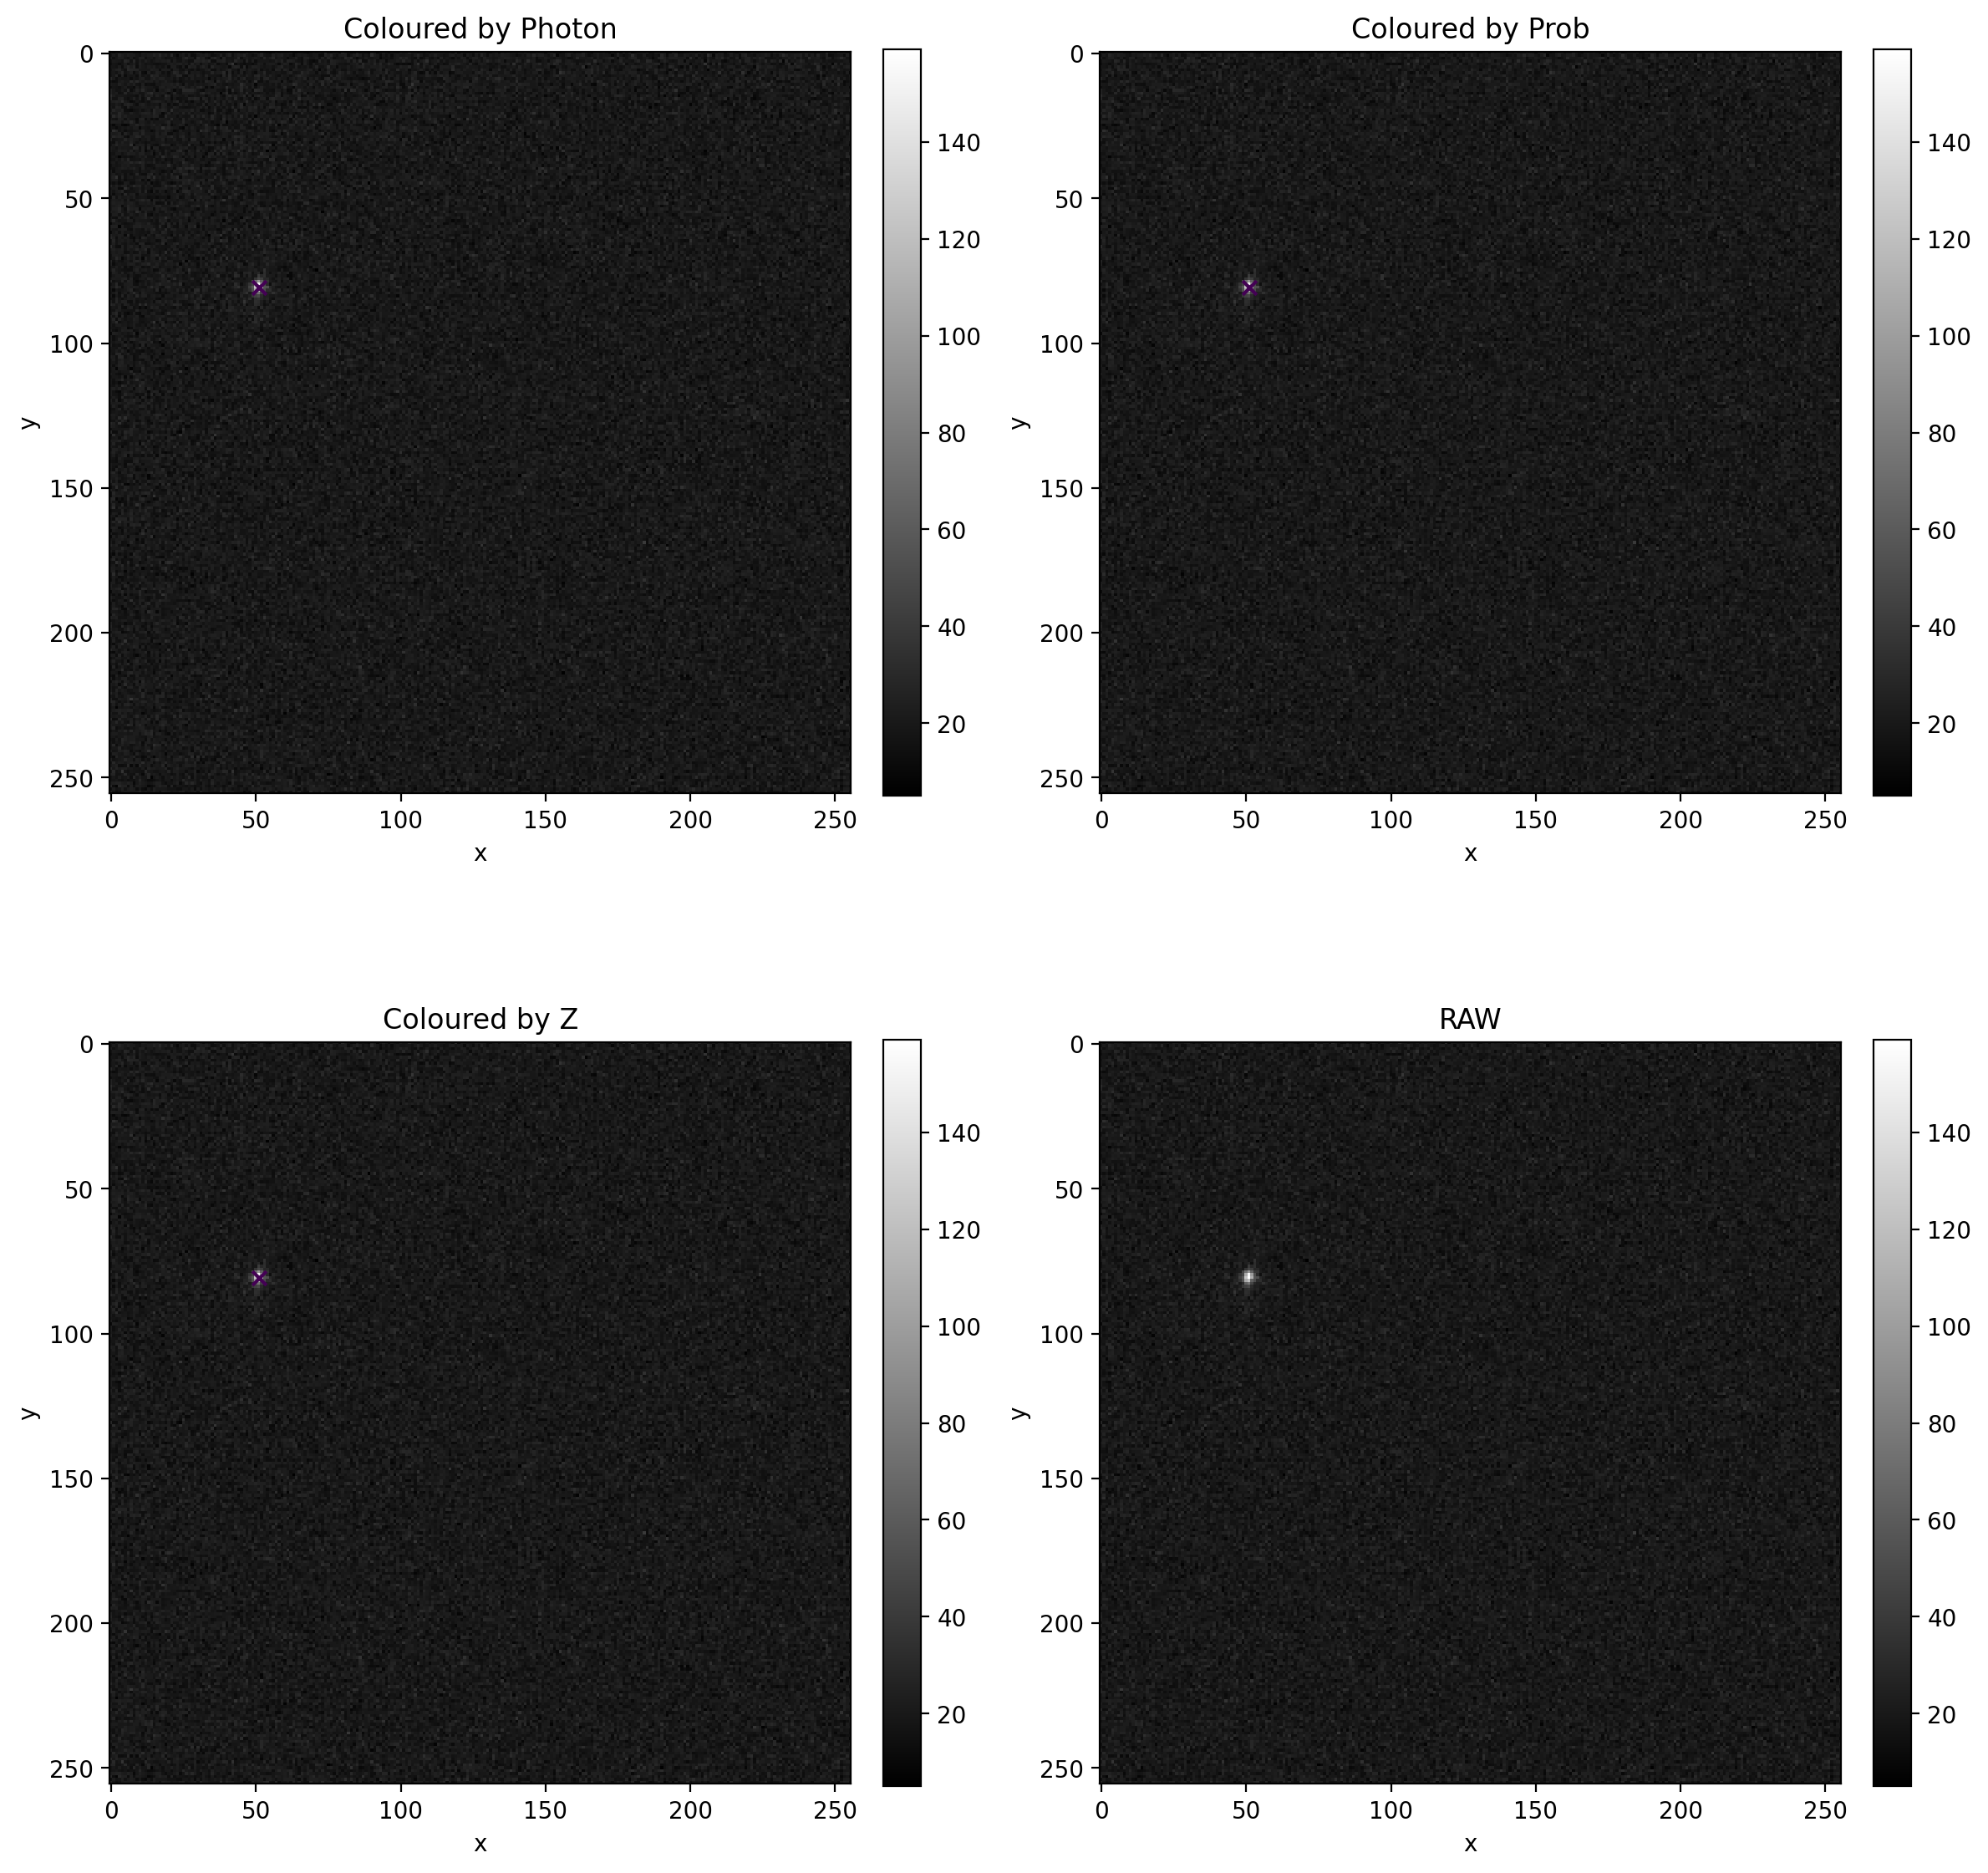

In [34]:
f_ix = 15000

x_plot = frames[0][f_ix]
e = em_out.iframe[f_ix]
ch = 0
clim = None

# f, ax = plt.subplots(figsize=(12, 12))

# plt.sca(ax)
# plt.title("Coloured by Prob")
# decode.plot.PlotFrameCoord(
#     x_plot,
#     pos_out=e.xyz_px,
#     phot_out=e.prob,
#     # pos_ini=e1.xyz_px,
#     # phot_ini=e1.phot,
#     clim=clim,
# ).plot()
# plt.show()

f, axs = plt.subplots(figsize=(12, 12), ncols=2, nrows=2)

axs = axs.flatten()

plt.sca(axs[0])
plt.title("Coloured by Photon")
decode.plot.PlotFrameCoord(
    x_plot,
    pos_out=e.xyz_px,
    phot_out=e.phot[:,0],
    # pos_ini=e1.xyz_px,
    # phot_ini=e1.phot,
    clim=clim,
).plot()


plt.sca(axs[1])
plt.title("Coloured by Prob")
decode.plot.PlotFrameCoord(
    x_plot,
    pos_out=e.xyz_px,
    phot_out=e.prob,
    # pos_ini=e1.xyz_px,
    # phot_ini=e1.prob,
    clim=clim,
).plot()

plt.sca(axs[2])
plt.title("Coloured by Z")
decode.plot.PlotFrameCoord(
    x_plot,
    pos_out=e.xyz_px,
    phot_out=e.xyz_px[:, 2],
    # pos_ini=e1.xyz_px,
    # phot_ini=e1.xyz_px[:, 2],
    clim=clim,
).plot()


plt.sca(axs[3])
plt.title("RAW")
decode.plot.PlotFrameCoord(
    x_plot,
    clim=clim,
).plot()

plt.tight_layout()
plt.show()

In [33]:
matcher = decode.evaluation.match_emittersets.GreedyHungarianMatching(
    match_dims=2, dist_ax=500., dist_lat=250.
)
ev = decode.evaluation.evaluation.SMLMEvaluation()

em_tar = em_ch.clone()
# em_tar.phot = em_tar.phot[:, 0]
em_tar.xyz_px = em_tar.xyz_px[:, 0]  # only first channel

em_eval = em_out[em_out.prob > 0.6]
# em_eval = em_eval[em_eval.phot > 1000]
em_eval = em_eval[em_eval.phot[:,0] > 1000]

em_eval.px_size = torch.tensor([100, 100])
em.px_size = torch.tensor([100, 100])

tp, fp, fn, tp_match = matcher.forward(em_eval, em_tar)

tp_match_g = tp_match.groupby("id", aggregate_fn=torch.nanmean, aggregate_fields=("xyz",))
tp_match_g = tp_match_g.collapse_on("id")
tp_match_g.xyz[:, :2] = float("nan")

tp_g = tp.groupby("id", aggregate_fn=torch.nanmean, aggregate_fields=("xyz", "xyz_sig", "phot", "phot_sig"))
tp_g = tp_g.collapse_on("id")

ev.forward(tp, fp, fn, tp_match)

{'prec': 1.0,
 'rec': 0.8185666666666667,
 'jac': 0.8185666666666667,
 'f1': 0.9002327840607072,
 'effcy_lat': 0.7912055932127993,
 'effcy_ax': 0.8071832085956346,
 'effcy_vol': 0.7991944009042169,
 'rmse_lat': 10.33298110961914,
 'rmse_ax': 13.054134368896484,
 'rmse_vol': 16.64875030517578,
 'mae_lat': 8.36368179321289,
 'mae_ax': 10.373746871948242,
 'mae_vol': 14.529830932617188,
 'mad_lat': 10.398961067199707,
 'mad_ax': 10.373746871948242,
 'mad_vol': 20.772706985473633,
 'acc_code': nan,
 'rmse_phot': [68.98104095458984, 68.98104095458984],
 'rmse_phot_pnorm': [1.379620909690857, 1.379620909690857],
 'dx_red_mu': nan,
 'dx_red_sig': nan,
 'dy_red_mu': nan,
 'dy_red_sig': nan,
 'dz_red_mu': nan,
 'dz_red_sig': nan,
 'dphot_red_mu': nan,
 'dphot_red_sig': nan}

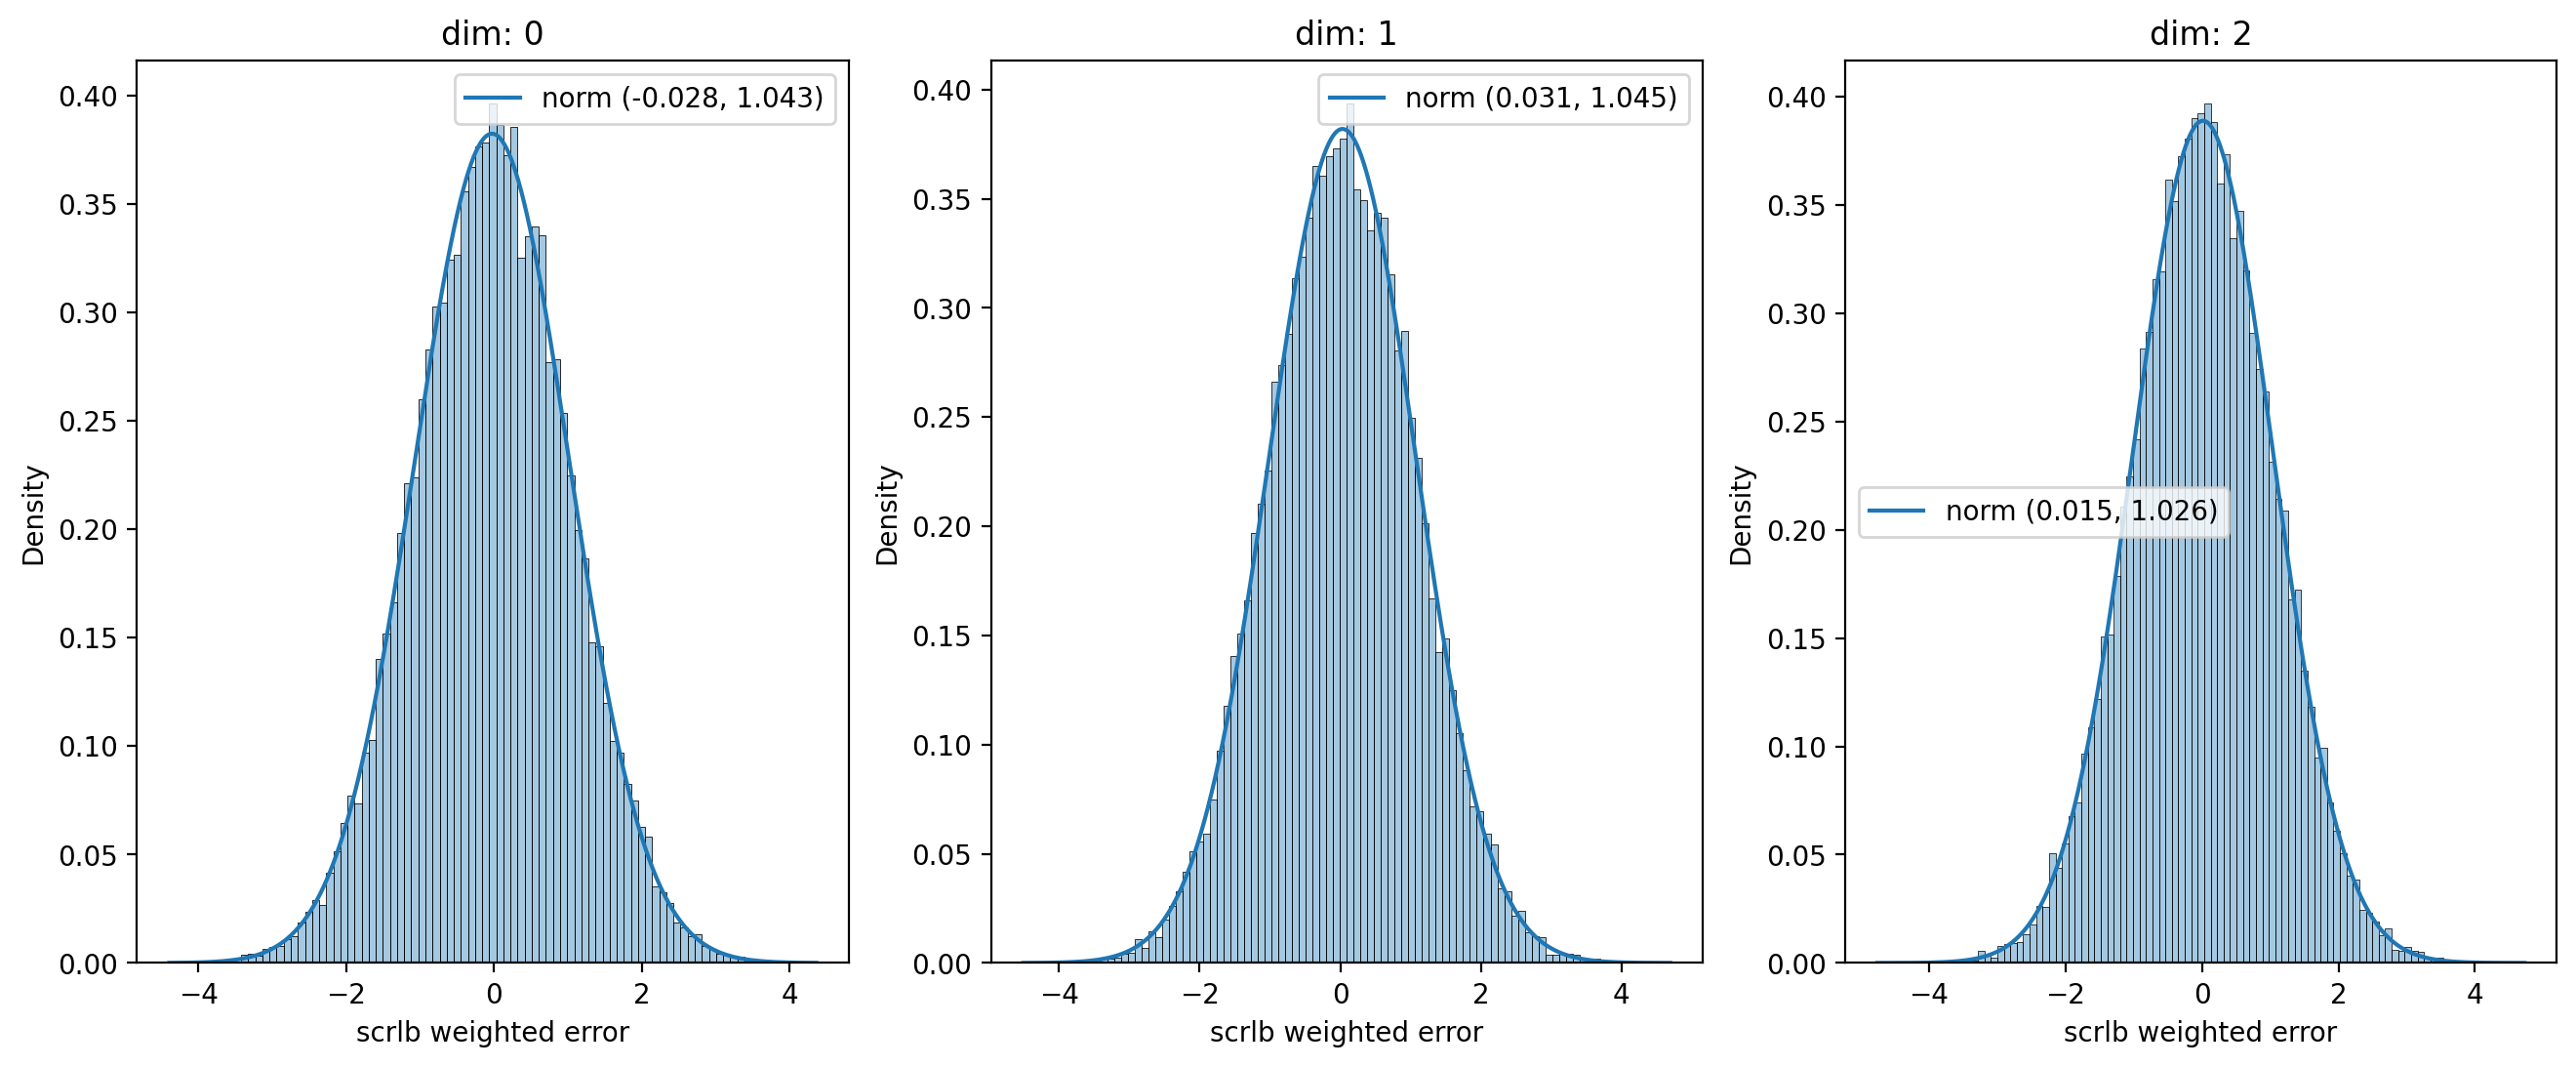

In [35]:
dscr = (tp.xyz_px - tp_match.xyz_px) / tp_match.xyz_scr

f, axs = plt.subplots(ncols=3, figsize=(16, 6))

for i, ax in enumerate(axs):
    decode.plot.deviation(dscr[:, i], ax=ax)
    ax.legend()
    ax.set_xlabel("scrlb weighted error")
    ax.set_title(f"dim: {i}")
    
    

# if path_out is not None:
#     plt.savefig(path_out / "crlb_hist.eps",format='eps', dpi=300, bbox_inches="tight")


## Figure

In [36]:
rmse = []

for ix in range(tp_match.id.max() + 1):
    d = tp_match[tp_match.id == ix].xyz_nm - tp[tp.id == ix].xyz_nm
    rmse.append(d.std(0))

rmse = torch.stack(rmse)

In [37]:
sigma = []

for ix in range(tp_match.id.max() + 1):
    d = tp[tp.id == ix].xyz_sig_nm
    sigma.append(d.mean(0))

sigma = torch.stack(sigma)

[27-04-2026 15:21:52] [matplotlib.backends.backend_ps] [WARNING] The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


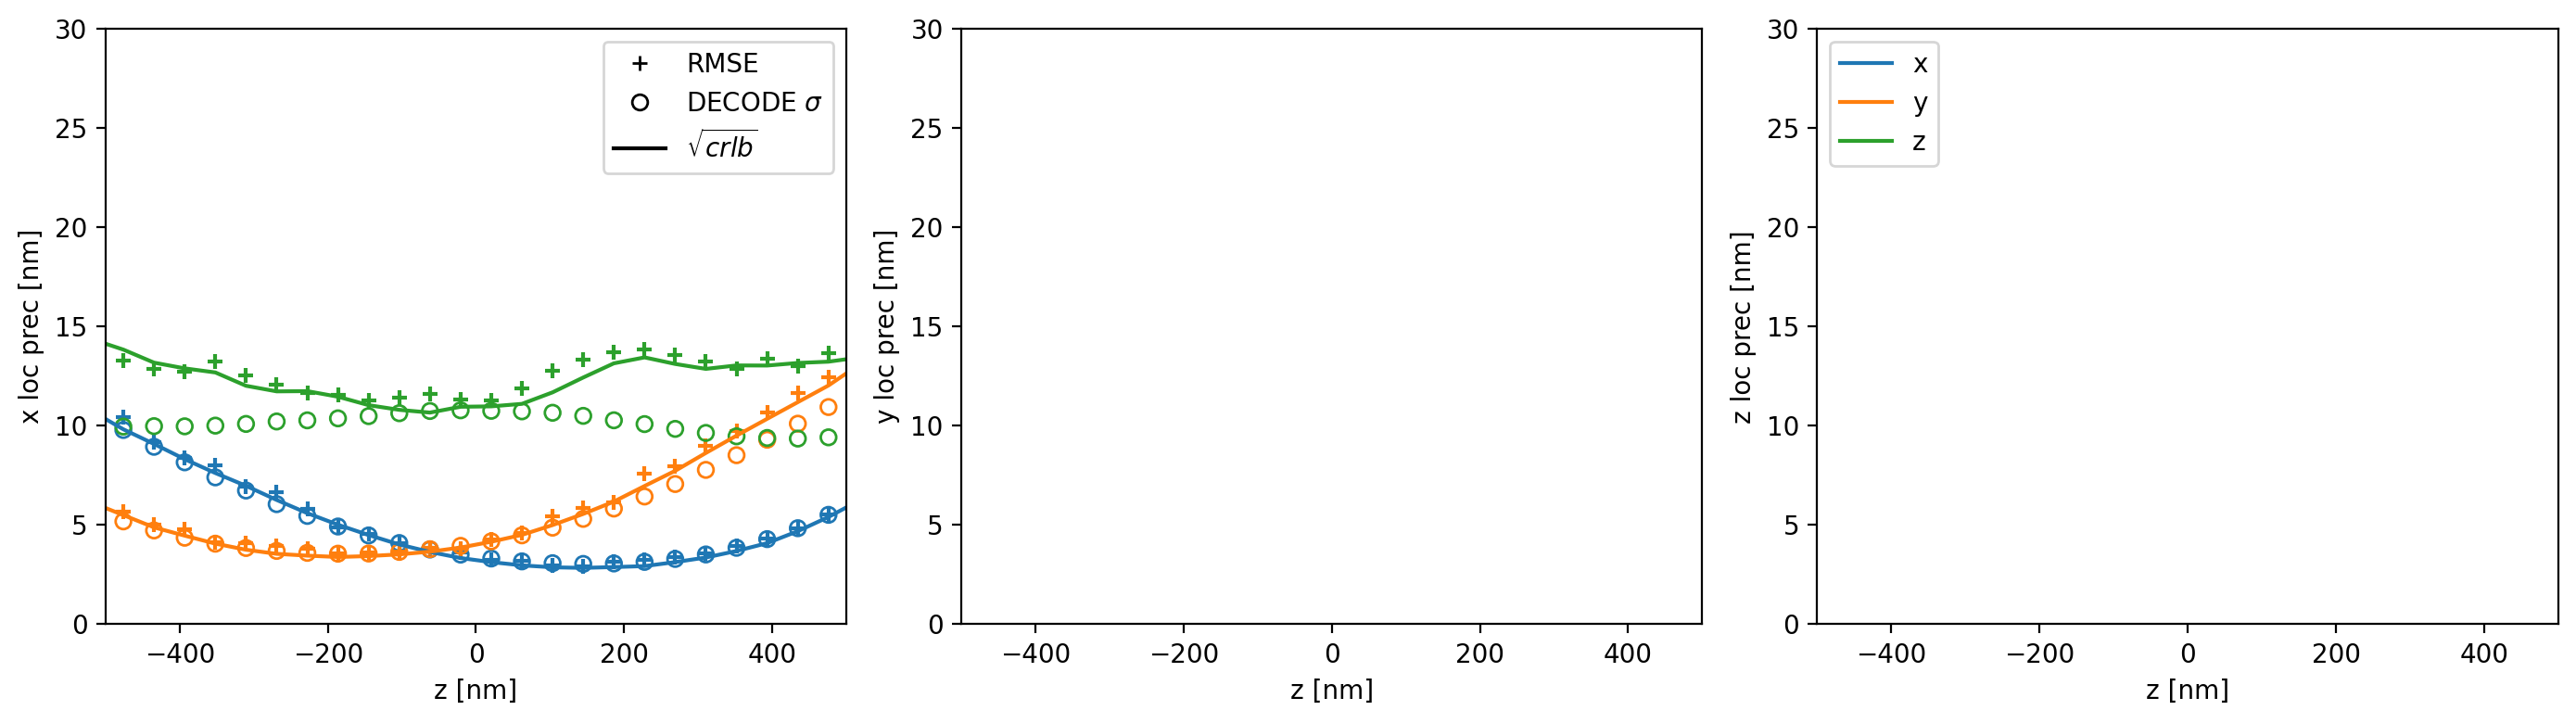

In [38]:
from matplotlib.lines import Line2D

step = slice(None, None, 1)

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]

f, axs = plt.subplots(ncols=3, figsize=(14, 4))
plt_lines = []
markers = []

for i, (dim, c, ax) in enumerate(zip(["x", "y", "z"], colors, axs)):
    (l,) = axs[0].plot(em.xyz_px[:, 2], em.xyz_scr_nm[:, i], color=c, label=f"{dim}")
    axs[0].scatter(
        tp_match_g.xyz[step, 2],
        # tp_g.xyz_sig_nm[step, i],
        sigma[step, i][~torch.isnan(sigma[step, i])],
        marker="o",
        facecolors="none",
        edgecolors=c,
    )
    m = axs[0].scatter(tp_match_g.xyz[step, 2], rmse[step, i], marker="+", c=c, edgecolors="face")

    plt_lines.append(l)
    markers.append(m)

# Create a legend for the lines
line_legend = ax.legend(handles=plt_lines, loc="upper left")

# Create a legend for the markers
marker_legend = axs[0].legend(
    [
        Line2D(
            [0], [0], marker="+", color="k", markerfacecolor="none", linestyle="None"
        ),
        Line2D(
            [0], [0], marker="o", color="k", markerfacecolor="none", linestyle="None"
        ),
        Line2D([0], [0], linestyle="-", color="black"),
    ],
    ["RMSE", r"DECODE $\sigma$", r"$\sqrt{crlb}$"],
    loc="upper right",
)

# Add the first legend manually to the current Axes.
# ax.add_artist(line_legend)

for ax in axs:
    ax.set_xlim(-500, 500)
    ax.set_ylim(0, 30)
    ax.set_xlabel("z [nm]")

ax_spec = [
    {"ylabel": "x loc prec [nm]"},
    {"ylabel": "y loc prec [nm]"},
    {"ylabel": "z loc prec [nm]"},
]

for ax, spec in zip(axs, ax_spec):
    ax.set_ylabel(spec["ylabel"])


plt.tight_layout()

if path_out is not None:
    plt.savefig(path_out / "crlb_curve.eps",format='eps', dpi=300, bbox_inches="tight")